# Task 2.2 — Patient Profile Experiments

## Digital Health Intervention Simulator — Notification Strategy Comparison Across Patient Profiles

This notebook implements **Task 2.2** of the AIBI lab assignment: modelling four patient profiles derived from the survey paper [3] and comparing five notification strategies (Random, Adaptive RF, DQN, PPO, A2C) for each profile.

### Patient Profiles (from Lisowska et al., "Personality and Habit Formation")

| Survey Question | Profile 0 | Profile 1 | Profile 2 | Profile 3 |
|---|:---:|:---:|:---:|:---:|
| Motivated when performing **better than peers** | No | No | **Yes** | Neutral |
| Keen to break **own record** | No | No | **Yes** | **Yes** |
| Keen when **competing with others** | No | No | **Yes** | Neutral |
| When **stressed → unlikely to respond** | No | **Yes** | **Yes** | Neutral |
| When **tired → unlikely to respond** | No | **Yes** | **Yes** | **Yes** |

## Fogg Behaviour Model Recap

The simulation is based on Fogg's Behaviour Model:

$$\text{Behaviour} = \begin{cases} 1 & \text{if } M \times A \times T > \text{threshold} \\ 0 & \text{otherwise} \end{cases}$$

Where:
- **M (Motivation)** = Valence + Family + Perceived Benefit + Sufficient Sleep (range 0–4)
- **A (Ability)** = Confidence + Low Load + Unstrained + Ready (range −1 to 4)
- **T (Trigger)** = (Arousal + Day + Time + Location + Motion) × Prompt (range 0–6)
- **Threshold** = 20 (set so ~70% of always-notify runs result in activity)

### Profile Implementation Decisions

- **Profile 0** — No overrides; base `Patient` already represents this neutral profile.
- **Profile 1** — `get_trigger() → 0` when stressed (arousal=2, valence=0); `get_ability() −2` when sleep < 7h.
- **Profile 2** — Motivation bonuses for peer comparison (+1) and personal record (+1); stress blocks trigger; fatigue penalises ability. Peer baseline pre-computed from 500 Profile 0 no-intervention runs.
- **Profile 3** — Record motivation bonus (+1); fatigue penalises ability; stress has base treatment only (neutral).

All profiles share the same `action_space`, `observation_space`, and `fogg_behavior()` — RL agents work without modification.

## Setup

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
from textwrap import wrap
from matplotlib import pyplot as plt
from stable_baselines3 import PPO, A2C, DQN
from sklearn.ensemble import RandomForestClassifier

from environment.fogg_behavioral_model import Patient
from environment.profile0 import Profile0Patient
from environment.profile1 import Profile1Patient
from environment.profile2 import Profile2Patient
from environment.profile3 import Profile3Patient

warnings.filterwarnings('ignore')

In [ ]:
# Constants
updated_every_day = 24
week = 7 * updated_every_day
eight_weeks = week * 8
five_weeks = week * 5

# Experimental condition
condition = 'stable'
habituation = False
time_preference_update_step = 9999999999999999

runs = 50  # TODO: SET TO 500 FOR FINAL

results_directory = 'results'
os.makedirs(results_directory, exist_ok=True)

## Helper Functions

Adapted from `experiments.ipynb` — the `intervention()` function is generalised to accept a `patient_factory` callable.

In [3]:
def intervention(method, runs, name, condition, patient_factory):
    """Run an intervention strategy for multiple runs using a patient factory."""
    rr_list = []
    not_list = []
    sleep_list = []
    positive_list = []
    performed = 0
    log_every = max(1, runs // 10)
    for run in range(runs):
        if run % log_every == 0 or run == runs - 1:
            print(f"  [{name}] run {run+1}/{runs}...")
        env1 = patient_factory()
        env1 = method(env1)
        if sum(env1.num_performed):
            performed += 1
        df = pd.DataFrame({
            'response_ratio': env1.rr,
            'activity performed': env1.num_performed,
            'notifications': env1.num_notified,
            'sleep': env1.h_slept,
            'positive': env1.h_positive,
            'non_stationary': env1.h_nonstationary
        })
        df.to_csv(f"{results_directory}/{name}_{condition}_run{run}.csv")
        rr_list.append(df.response_ratio)
        not_list.append(df.notifications)
        sleep_list.append(df.sleep)
        positive_list.append(df.positive)
    print(f"  [{name}] done — {performed} / {runs} runs had activity performed")
    return sleep_list, positive_list, rr_list, not_list

In [4]:
def always_notify(env1, intervention_legth=eight_weeks):
    action = 0
    for i in range(intervention_legth):
        observation, reward, terminated, truncated, info = env1.step(action)
        if observation[9] == 3 or observation[3] == 1:
            action = 0
        else:
            action = 1
    return env1


def random_notification(env1, intervention_legth=eight_weeks):
    action = 0
    for i in range(intervention_legth):
        observation, reward, terminated, truncated, info = env1.step(action)
        if observation[9] == 3:
            action = 0
        else:
            action = env1.action_space.sample()
    return env1

In [5]:
def supervised_adaptive_after_three_weeks(env1):
    three_weeks = 24 * 7 * 3
    env1 = always_notify(env1, intervention_legth=three_weeks)
    if len(set(env1.activity_performed)) < 2:
        remaining_time = eight_weeks - three_weeks
        for _ in range(remaining_time):
            env1.step(0)
        return env1
    clf = RandomForestClassifier(class_weight='balanced')
    clf.fit(env1.observation_list, env1.activity_performed)
    remaining_time = eight_weeks - three_weeks
    observation = env1._get_current_state()
    samples = len(env1.observation_list)
    for i in range(remaining_time):
        action = clf.predict(np.array([observation]))[0]
        observation, reward, terminated, truncated, info = env1.step(action)
        if len(env1.observation_list) > samples:
            if len(set(env1.activity_performed)) >= 2:
                clf = RandomForestClassifier(class_weight='balanced')
                clf.fit(env1.observation_list, env1.activity_performed)
            samples = len(env1.observation_list)
    return env1

In [6]:
def dqn(env1):
    model = DQN("MlpPolicy", env1, verbose=0, learning_starts=updated_every_day)
    model.learn(total_timesteps=eight_weeks)
    return env1


def ppo(env1):
    model = PPO("MlpPolicy", env1, verbose=0, n_steps=updated_every_day, batch_size=updated_every_day)
    model.learn(total_timesteps=eight_weeks)
    return env1


def a2c(env1):
    model = A2C("MlpPolicy", env1, verbose=0, n_steps=updated_every_day)
    model.learn(total_timesteps=eight_weeks)
    return env1

In [7]:
def get_rr_and_notification(name, runs, condition):
    rr, noti = [], []
    failed = 0
    for run in range(runs):
        df = pd.read_csv(f"{results_directory}/{name}_{condition}_run{run}.csv")
        a_performed = sum(df['activity performed'].values)
        if a_performed > 0:
            rr.append(df.response_ratio)
            noti.append(df.notifications)
        else:
            failed += 1
    print(f"{name}: {failed} out of {runs} runs had no activity performed.")
    return rr, noti, failed

## Peer Baseline Computation (for Profile 2)

Run 500 Profile 0 patients under no intervention to establish the mean daily response ratio that a "typical" neutral patient achieves. This is cached to `results/peer_baseline.npy`.

In [8]:
peer_baseline_path = os.path.join(results_directory, 'peer_baseline.npy')

if os.path.exists(peer_baseline_path):
    peer_rr_baseline = np.load(peer_baseline_path)
    print(f"Loaded cached peer baseline: shape {peer_rr_baseline.shape}")
else:
    print(f"Computing peer baseline from {runs} Profile 0 no-intervention runs...")
    rr_matrix = []
    for i in range(runs):
        env = Profile0Patient(
            behavior_threshold=20, habituation=False,
            time_preference_update_step=time_preference_update_step
        )
        for _ in range(eight_weeks):
            env.step(0)
        rr_matrix.append(env.rr)
    peer_rr_baseline = np.nanmean(rr_matrix, axis=0)
    np.save(peer_baseline_path, peer_rr_baseline)
    print(f"Saved peer baseline: shape {peer_rr_baseline.shape}")

Loaded cached peer baseline: shape (56,)


## Patient Factories

In [9]:
profile0_factory = lambda: Profile0Patient(
    behavior_threshold=20, habituation=habituation,
    time_preference_update_step=time_preference_update_step)

profile1_factory = lambda: Profile1Patient(
    behavior_threshold=20, habituation=habituation,
    time_preference_update_step=time_preference_update_step)

profile2_factory = lambda: Profile2Patient(
    behavior_threshold=20, habituation=habituation,
    time_preference_update_step=time_preference_update_step,
    peer_rr_baseline=peer_rr_baseline)

profile3_factory = lambda: Profile3Patient(
    behavior_threshold=20, habituation=habituation,
    time_preference_update_step=time_preference_update_step)

## Profile 0 Experiments — Neutral / Low-Sensitivity Patient

Profile 0 is essentially the base patient. No peer comparison, no record motivation, no special stress/fatigue sensitivity.

In [10]:
print("=== Profile 0: Random ===")
p0_sleep_rand, p0_pos_rand, p0_rr_rand, p0_not_rand = intervention(
    random_notification, runs, 'p0_random', condition, profile0_factory)

print("\n=== Profile 0: Adaptive RF ===")
p0_sleep_rf, p0_pos_rf, p0_rr_rf, p0_not_rf = intervention(
    supervised_adaptive_after_three_weeks, runs, 'p0_adaptive', condition, profile0_factory)

print("\n=== Profile 0: DQN ===")
p0_sleep_dqn, p0_pos_dqn, p0_rr_dqn, p0_not_dqn = intervention(
    dqn, runs, 'p0_dqn', condition, profile0_factory)

print("\n=== Profile 0: PPO ===")
p0_sleep_ppo, p0_pos_ppo, p0_rr_ppo, p0_not_ppo = intervention(
    ppo, runs, 'p0_ppo', condition, profile0_factory)

print("\n=== Profile 0: A2C ===")
p0_sleep_a2c, p0_pos_a2c, p0_rr_a2c, p0_not_a2c = intervention(
    a2c, runs, 'p0_a2c', condition, profile0_factory)

=== Profile 0: Random ===
  [p0_random] run 1/50...
  [p0_random] run 6/50...
  [p0_random] run 11/50...
  [p0_random] run 16/50...
  [p0_random] run 21/50...
  [p0_random] run 26/50...
  [p0_random] run 31/50...
  [p0_random] run 36/50...
  [p0_random] run 41/50...
  [p0_random] run 46/50...
  [p0_random] run 50/50...
  [p0_random] done — 35 / 50 runs had activity performed

=== Profile 0: Adaptive RF ===
  [p0_adaptive] run 1/50...
  [p0_adaptive] run 6/50...
  [p0_adaptive] run 11/50...
  [p0_adaptive] run 16/50...
  [p0_adaptive] run 21/50...
  [p0_adaptive] run 26/50...
  [p0_adaptive] run 31/50...
  [p0_adaptive] run 36/50...
  [p0_adaptive] run 41/50...
  [p0_adaptive] run 46/50...
  [p0_adaptive] run 50/50...
  [p0_adaptive] done — 20 / 50 runs had activity performed

=== Profile 0: DQN ===
  [p0_dqn] run 1/50...
  [p0_dqn] run 6/50...
  [p0_dqn] run 11/50...
  [p0_dqn] run 16/50...
  [p0_dqn] run 21/50...
  [p0_dqn] run 26/50...
  [p0_dqn] run 31/50...
  [p0_dqn] run 36/50...


In [11]:
# Filter failed runs for Profile 0
p0_rr_rand_f, p0_not_rand_f, p0_f_rand = get_rr_and_notification('p0_random', runs, condition)
p0_rr_rf_f, p0_not_rf_f, p0_f_rf = get_rr_and_notification('p0_adaptive', runs, condition)
p0_rr_dqn_f, p0_not_dqn_f, p0_f_dqn = get_rr_and_notification('p0_dqn', runs, condition)
p0_rr_ppo_f, p0_not_ppo_f, p0_f_ppo = get_rr_and_notification('p0_ppo', runs, condition)
p0_rr_a2c_f, p0_not_a2c_f, p0_f_a2c = get_rr_and_notification('p0_a2c', runs, condition)

p0_random: 15 out of 50 runs had no activity performed.
p0_adaptive: 30 out of 50 runs had no activity performed.
p0_dqn: 26 out of 50 runs had no activity performed.
p0_ppo: 20 out of 50 runs had no activity performed.
p0_a2c: 20 out of 50 runs had no activity performed.


## Profile 1 Experiments — Stress-and-Fatigue-Sensitive Patient

When stressed (arousal=2, valence=0), trigger collapses to 0 → patient **never** responds. Insufficient sleep (<7h) penalises ability by −2.

In [12]:
print("=== Profile 1: Random ===")
p1_sleep_rand, p1_pos_rand, p1_rr_rand, p1_not_rand = intervention(
    random_notification, runs, 'p1_random', condition, profile1_factory)

print("\n=== Profile 1: Adaptive RF ===")
p1_sleep_rf, p1_pos_rf, p1_rr_rf, p1_not_rf = intervention(
    supervised_adaptive_after_three_weeks, runs, 'p1_adaptive', condition, profile1_factory)

print("\n=== Profile 1: DQN ===")
p1_sleep_dqn, p1_pos_dqn, p1_rr_dqn, p1_not_dqn = intervention(
    dqn, runs, 'p1_dqn', condition, profile1_factory)

print("\n=== Profile 1: PPO ===")
p1_sleep_ppo, p1_pos_ppo, p1_rr_ppo, p1_not_ppo = intervention(
    ppo, runs, 'p1_ppo', condition, profile1_factory)

print("\n=== Profile 1: A2C ===")
p1_sleep_a2c, p1_pos_a2c, p1_rr_a2c, p1_not_a2c = intervention(
    a2c, runs, 'p1_a2c', condition, profile1_factory)

=== Profile 1: Random ===
  [p1_random] run 1/50...
  [p1_random] run 6/50...
  [p1_random] run 11/50...
  [p1_random] run 16/50...
  [p1_random] run 21/50...
  [p1_random] run 26/50...
  [p1_random] run 31/50...
  [p1_random] run 36/50...
  [p1_random] run 41/50...
  [p1_random] run 46/50...
  [p1_random] run 50/50...
  [p1_random] done — 40 / 50 runs had activity performed

=== Profile 1: Adaptive RF ===
  [p1_adaptive] run 1/50...
  [p1_adaptive] run 6/50...
  [p1_adaptive] run 11/50...
  [p1_adaptive] run 16/50...
  [p1_adaptive] run 21/50...
  [p1_adaptive] run 26/50...
  [p1_adaptive] run 31/50...
  [p1_adaptive] run 36/50...
  [p1_adaptive] run 41/50...
  [p1_adaptive] run 46/50...
  [p1_adaptive] run 50/50...
  [p1_adaptive] done — 24 / 50 runs had activity performed

=== Profile 1: DQN ===
  [p1_dqn] run 1/50...
  [p1_dqn] run 6/50...
  [p1_dqn] run 11/50...
  [p1_dqn] run 16/50...
  [p1_dqn] run 21/50...
  [p1_dqn] run 26/50...
  [p1_dqn] run 31/50...
  [p1_dqn] run 36/50...


In [13]:
p1_rr_rand_f, p1_not_rand_f, p1_f_rand = get_rr_and_notification('p1_random', runs, condition)
p1_rr_rf_f, p1_not_rf_f, p1_f_rf = get_rr_and_notification('p1_adaptive', runs, condition)
p1_rr_dqn_f, p1_not_dqn_f, p1_f_dqn = get_rr_and_notification('p1_dqn', runs, condition)
p1_rr_ppo_f, p1_not_ppo_f, p1_f_ppo = get_rr_and_notification('p1_ppo', runs, condition)
p1_rr_a2c_f, p1_not_a2c_f, p1_f_a2c = get_rr_and_notification('p1_a2c', runs, condition)

p1_random: 10 out of 50 runs had no activity performed.
p1_adaptive: 26 out of 50 runs had no activity performed.
p1_dqn: 22 out of 50 runs had no activity performed.
p1_ppo: 27 out of 50 runs had no activity performed.
p1_a2c: 14 out of 50 runs had no activity performed.


## Profile 2 Experiments — Competitive and Peer-Motivated Patient

Motivation bonuses from peer comparison (+1 if outperforming peer baseline) and personal record (+1 if on pace). Retains stress block and fatigue penalty from Profile 1.

In [14]:
print("=== Profile 2: Random ===")
p2_sleep_rand, p2_pos_rand, p2_rr_rand, p2_not_rand = intervention(
    random_notification, runs, 'p2_random', condition, profile2_factory)

print("\n=== Profile 2: Adaptive RF ===")
p2_sleep_rf, p2_pos_rf, p2_rr_rf, p2_not_rf = intervention(
    supervised_adaptive_after_three_weeks, runs, 'p2_adaptive', condition, profile2_factory)

print("\n=== Profile 2: DQN ===")
p2_sleep_dqn, p2_pos_dqn, p2_rr_dqn, p2_not_dqn = intervention(
    dqn, runs, 'p2_dqn', condition, profile2_factory)

print("\n=== Profile 2: PPO ===")
p2_sleep_ppo, p2_pos_ppo, p2_rr_ppo, p2_not_ppo = intervention(
    ppo, runs, 'p2_ppo', condition, profile2_factory)

print("\n=== Profile 2: A2C ===")
p2_sleep_a2c, p2_pos_a2c, p2_rr_a2c, p2_not_a2c = intervention(
    a2c, runs, 'p2_a2c', condition, profile2_factory)

=== Profile 2: Random ===
  [p2_random] run 1/50...
  [p2_random] run 6/50...
  [p2_random] run 11/50...
  [p2_random] run 16/50...
  [p2_random] run 21/50...
  [p2_random] run 26/50...
  [p2_random] run 31/50...
  [p2_random] run 36/50...
  [p2_random] run 41/50...
  [p2_random] run 46/50...
  [p2_random] run 50/50...
  [p2_random] done — 50 / 50 runs had activity performed

=== Profile 2: Adaptive RF ===
  [p2_adaptive] run 1/50...
  [p2_adaptive] run 6/50...
  [p2_adaptive] run 11/50...
  [p2_adaptive] run 16/50...
  [p2_adaptive] run 21/50...
  [p2_adaptive] run 26/50...
  [p2_adaptive] run 31/50...
  [p2_adaptive] run 36/50...
  [p2_adaptive] run 41/50...
  [p2_adaptive] run 46/50...
  [p2_adaptive] run 50/50...
  [p2_adaptive] done — 37 / 50 runs had activity performed

=== Profile 2: DQN ===
  [p2_dqn] run 1/50...
  [p2_dqn] run 6/50...
  [p2_dqn] run 11/50...
  [p2_dqn] run 16/50...
  [p2_dqn] run 21/50...
  [p2_dqn] run 26/50...
  [p2_dqn] run 31/50...
  [p2_dqn] run 36/50...


In [15]:
p2_rr_rand_f, p2_not_rand_f, p2_f_rand = get_rr_and_notification('p2_random', runs, condition)
p2_rr_rf_f, p2_not_rf_f, p2_f_rf = get_rr_and_notification('p2_adaptive', runs, condition)
p2_rr_dqn_f, p2_not_dqn_f, p2_f_dqn = get_rr_and_notification('p2_dqn', runs, condition)
p2_rr_ppo_f, p2_not_ppo_f, p2_f_ppo = get_rr_and_notification('p2_ppo', runs, condition)
p2_rr_a2c_f, p2_not_a2c_f, p2_f_a2c = get_rr_and_notification('p2_a2c', runs, condition)

p2_random: 0 out of 50 runs had no activity performed.
p2_adaptive: 13 out of 50 runs had no activity performed.
p2_dqn: 13 out of 50 runs had no activity performed.
p2_ppo: 11 out of 50 runs had no activity performed.
p2_a2c: 6 out of 50 runs had no activity performed.


## Profile 3 Experiments — Personal-Record-Driven Patient

Motivation bonus from personal record (+1). Fatigue-sensitive (ability −2 if sleep <7h). Stress-neutral (no trigger collapse).

In [16]:
print("=== Profile 3: Random ===")
p3_sleep_rand, p3_pos_rand, p3_rr_rand, p3_not_rand = intervention(
    random_notification, runs, 'p3_random', condition, profile3_factory)

print("\n=== Profile 3: Adaptive RF ===")
p3_sleep_rf, p3_pos_rf, p3_rr_rf, p3_not_rf = intervention(
    supervised_adaptive_after_three_weeks, runs, 'p3_adaptive', condition, profile3_factory)

print("\n=== Profile 3: DQN ===")
p3_sleep_dqn, p3_pos_dqn, p3_rr_dqn, p3_not_dqn = intervention(
    dqn, runs, 'p3_dqn', condition, profile3_factory)

print("\n=== Profile 3: PPO ===")
p3_sleep_ppo, p3_pos_ppo, p3_rr_ppo, p3_not_ppo = intervention(
    ppo, runs, 'p3_ppo', condition, profile3_factory)

print("\n=== Profile 3: A2C ===")
p3_sleep_a2c, p3_pos_a2c, p3_rr_a2c, p3_not_a2c = intervention(
    a2c, runs, 'p3_a2c', condition, profile3_factory)

=== Profile 3: Random ===
  [p3_random] run 1/50...
  [p3_random] run 6/50...
  [p3_random] run 11/50...
  [p3_random] run 16/50...
  [p3_random] run 21/50...
  [p3_random] run 26/50...
  [p3_random] run 31/50...
  [p3_random] run 36/50...
  [p3_random] run 41/50...
  [p3_random] run 46/50...
  [p3_random] run 50/50...
  [p3_random] done — 49 / 50 runs had activity performed

=== Profile 3: Adaptive RF ===
  [p3_adaptive] run 1/50...
  [p3_adaptive] run 6/50...
  [p3_adaptive] run 11/50...
  [p3_adaptive] run 16/50...
  [p3_adaptive] run 21/50...
  [p3_adaptive] run 26/50...
  [p3_adaptive] run 31/50...
  [p3_adaptive] run 36/50...
  [p3_adaptive] run 41/50...
  [p3_adaptive] run 46/50...
  [p3_adaptive] run 50/50...
  [p3_adaptive] done — 38 / 50 runs had activity performed

=== Profile 3: DQN ===
  [p3_dqn] run 1/50...
  [p3_dqn] run 6/50...
  [p3_dqn] run 11/50...
  [p3_dqn] run 16/50...
  [p3_dqn] run 21/50...
  [p3_dqn] run 26/50...
  [p3_dqn] run 31/50...
  [p3_dqn] run 36/50...


In [17]:
p3_rr_rand_f, p3_not_rand_f, p3_f_rand = get_rr_and_notification('p3_random', runs, condition)
p3_rr_rf_f, p3_not_rf_f, p3_f_rf = get_rr_and_notification('p3_adaptive', runs, condition)
p3_rr_dqn_f, p3_not_dqn_f, p3_f_dqn = get_rr_and_notification('p3_dqn', runs, condition)
p3_rr_ppo_f, p3_not_ppo_f, p3_f_ppo = get_rr_and_notification('p3_ppo', runs, condition)
p3_rr_a2c_f, p3_not_a2c_f, p3_f_a2c = get_rr_and_notification('p3_a2c', runs, condition)

p3_random: 1 out of 50 runs had no activity performed.
p3_adaptive: 12 out of 50 runs had no activity performed.
p3_dqn: 13 out of 50 runs had no activity performed.
p3_ppo: 9 out of 50 runs had no activity performed.
p3_a2c: 6 out of 50 runs had no activity performed.


## Per-Profile Comparison Plots

For each profile: response ratio and notification count over intervention days.

In [18]:
def plot_profile_comparison(profile_name, rr_dict, not_dict):
    """Two-panel plot: response ratio & notifications per day for one profile."""
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(10, 8))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    for i, (label, rr) in enumerate(rr_dict.items()):
        if len(rr) > 0:
            ax1.plot(np.nanmean(rr, axis=0), label=label, color=colors[i])
    for i, (label, noti) in enumerate(not_dict.items()):
        if len(noti) > 0:
            ax2.plot(np.nanmean(noti, axis=0), label=label, color=colors[i])
    ax2.axhline(y=3, linestyle='--', color='grey', label='Max preferred (3/day)')
    ax1.set_ylabel('\n'.join(wrap('Activity performed to prompt ratio', 20)), fontsize=13)
    ax2.set_ylabel('\n'.join(wrap('Number of notifications', 20)), fontsize=13)
    ax2.set_xlabel('Intervention Days', fontsize=13)
    ax1.set_title(f'{profile_name} — Notification Strategy Comparison', fontsize=14)
    ax1.legend(fontsize=11)
    ax2.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

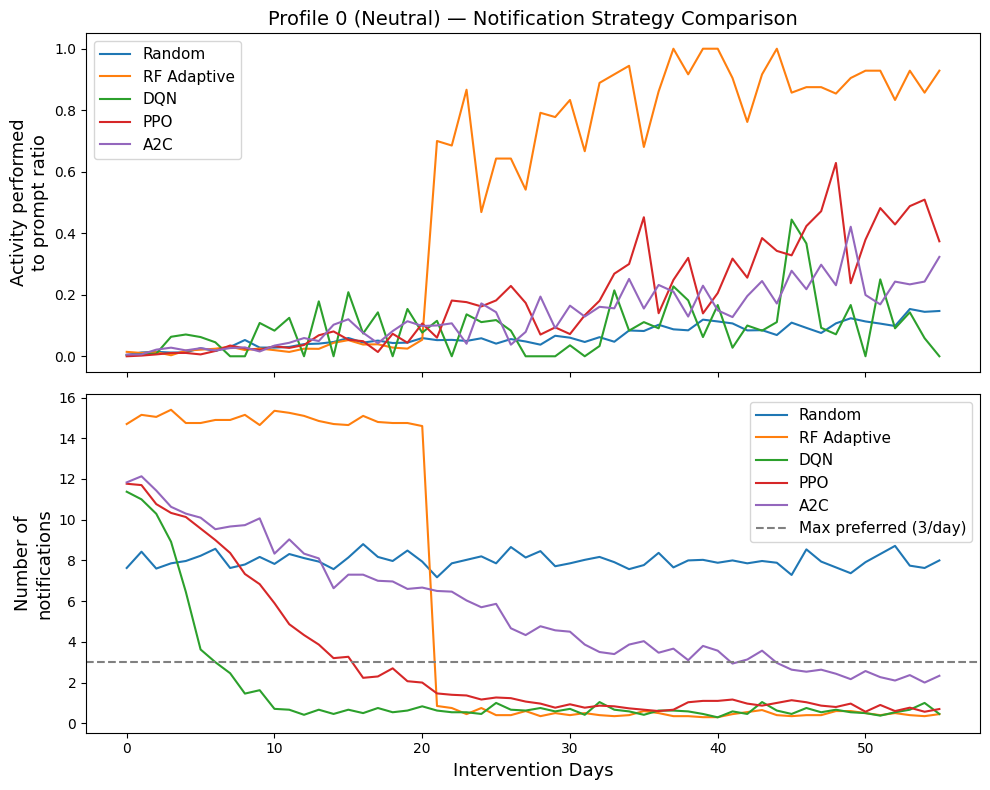

In [19]:
plot_profile_comparison('Profile 0 (Neutral)',
    {'Random': p0_rr_rand_f, 'RF Adaptive': p0_rr_rf_f, 'DQN': p0_rr_dqn_f, 'PPO': p0_rr_ppo_f, 'A2C': p0_rr_a2c_f},
    {'Random': p0_not_rand_f, 'RF Adaptive': p0_not_rf_f, 'DQN': p0_not_dqn_f, 'PPO': p0_not_ppo_f, 'A2C': p0_not_a2c_f})

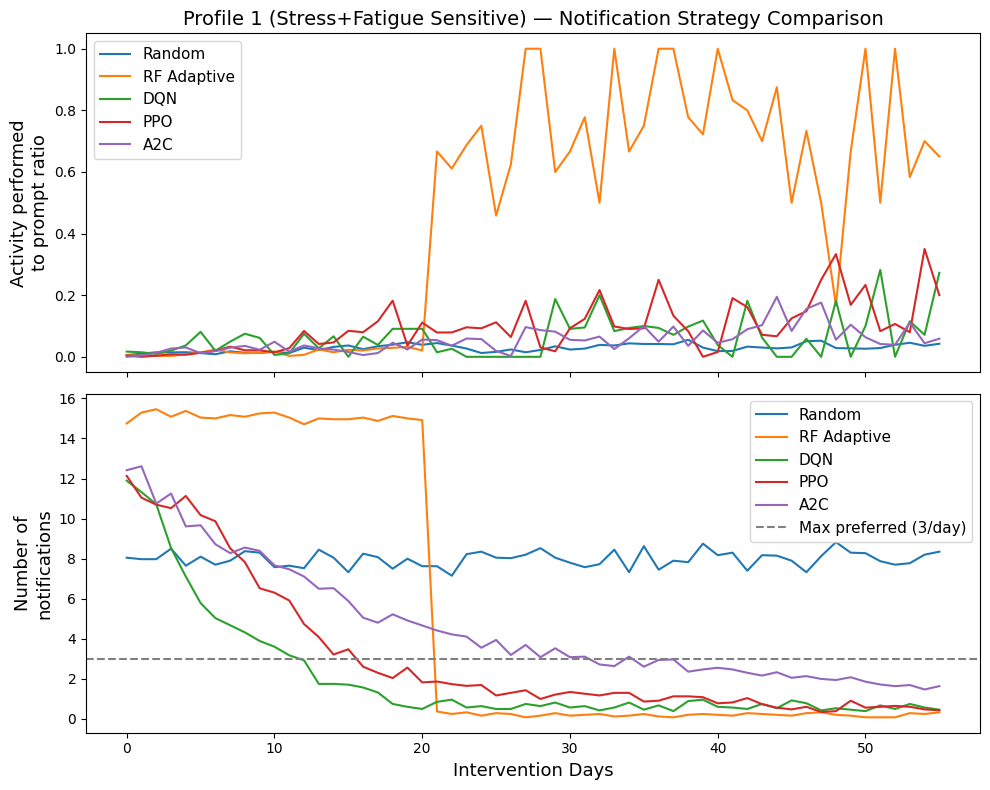

In [20]:
plot_profile_comparison('Profile 1 (Stress+Fatigue Sensitive)',
    {'Random': p1_rr_rand_f, 'RF Adaptive': p1_rr_rf_f, 'DQN': p1_rr_dqn_f, 'PPO': p1_rr_ppo_f, 'A2C': p1_rr_a2c_f},
    {'Random': p1_not_rand_f, 'RF Adaptive': p1_not_rf_f, 'DQN': p1_not_dqn_f, 'PPO': p1_not_ppo_f, 'A2C': p1_not_a2c_f})

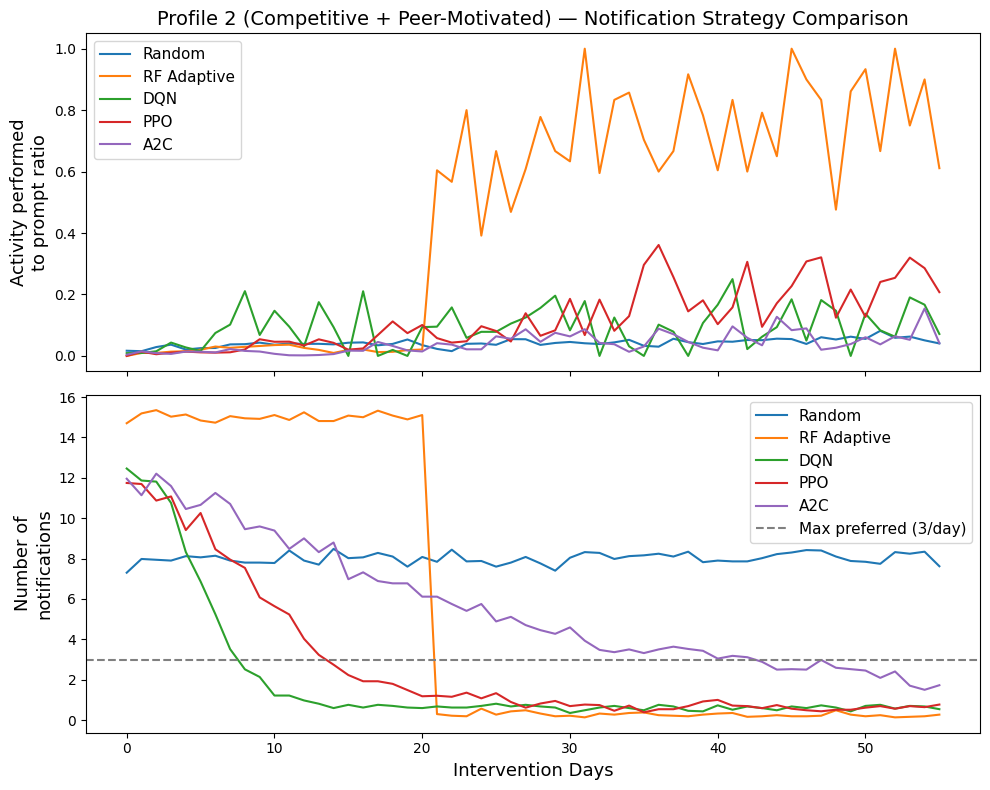

In [21]:
plot_profile_comparison('Profile 2 (Competitive + Peer-Motivated)',
    {'Random': p2_rr_rand_f, 'RF Adaptive': p2_rr_rf_f, 'DQN': p2_rr_dqn_f, 'PPO': p2_rr_ppo_f, 'A2C': p2_rr_a2c_f},
    {'Random': p2_not_rand_f, 'RF Adaptive': p2_not_rf_f, 'DQN': p2_not_dqn_f, 'PPO': p2_not_ppo_f, 'A2C': p2_not_a2c_f})

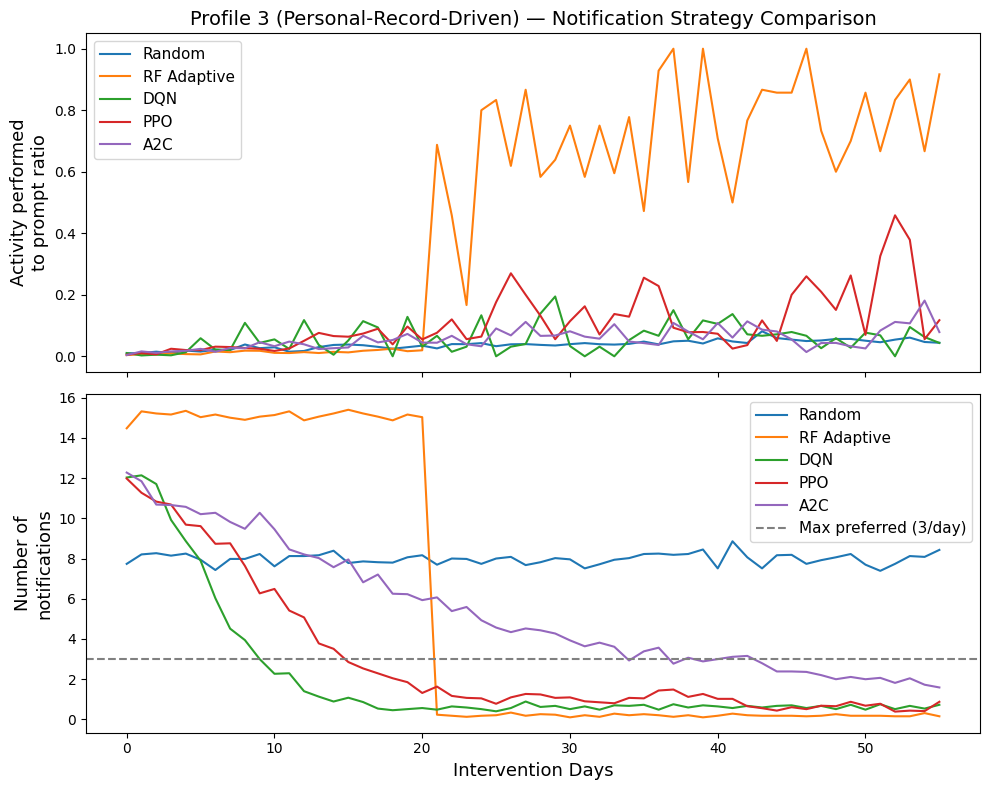

In [22]:
plot_profile_comparison('Profile 3 (Personal-Record-Driven)',
    {'Random': p3_rr_rand_f, 'RF Adaptive': p3_rr_rf_f, 'DQN': p3_rr_dqn_f, 'PPO': p3_rr_ppo_f, 'A2C': p3_rr_a2c_f},
    {'Random': p3_not_rand_f, 'RF Adaptive': p3_not_rf_f, 'DQN': p3_not_dqn_f, 'PPO': p3_not_ppo_f, 'A2C': p3_not_a2c_f})

## Cross-Profile Comparison Plots

One figure per strategy showing all 4 profiles, to identify which profiles benefit most from each approach.

In [23]:
def plot_cross_profile(strategy_name, rr_per_profile):
    """Plot response ratio for all profiles under one strategy."""
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for i, (pname, rr_data) in enumerate(rr_per_profile.items()):
        if len(rr_data) > 0:
            ax.plot(np.nanmean(rr_data, axis=0), label=pname, color=colors[i])
    ax.set_ylabel('Response Ratio', fontsize=13)
    ax.set_xlabel('Intervention Days', fontsize=13)
    ax.set_title(f'{strategy_name} — All Profiles', fontsize=14)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

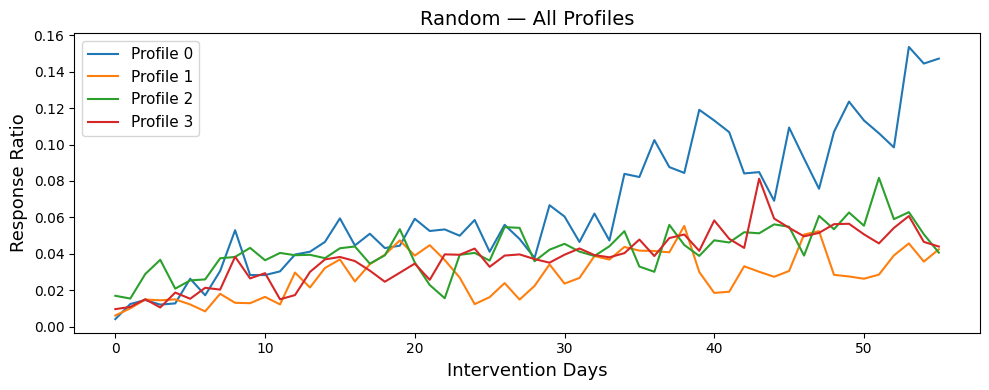

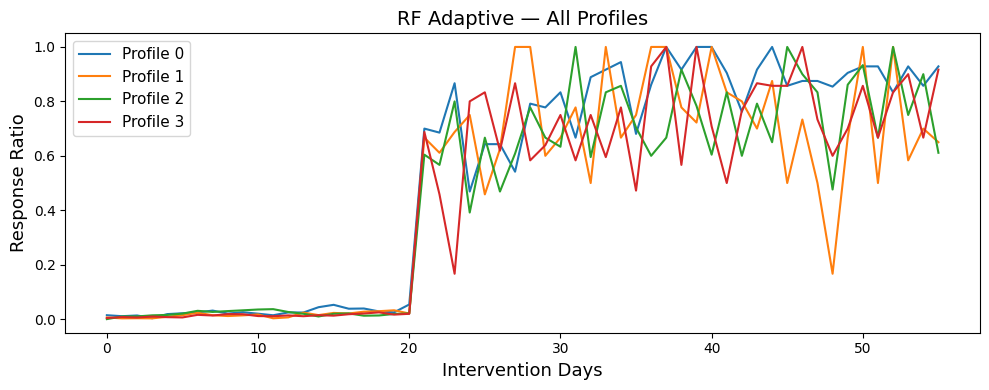

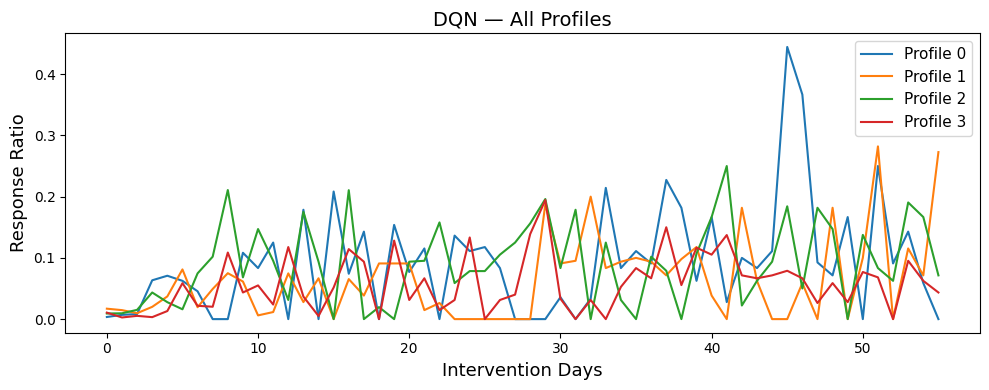

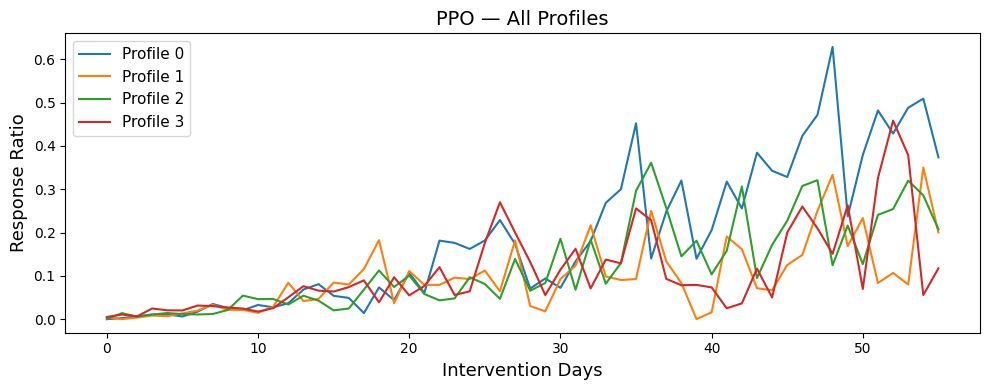

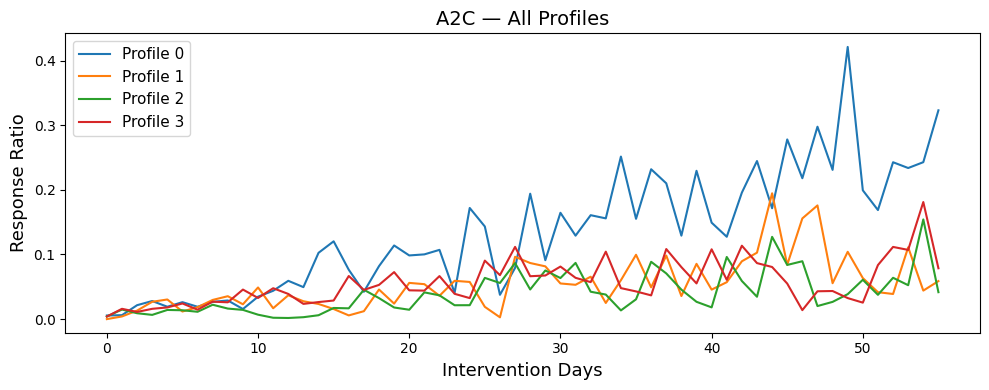

In [24]:
profiles = {
    'Profile 0': (p0_rr_rand_f, p0_rr_rf_f, p0_rr_dqn_f, p0_rr_ppo_f, p0_rr_a2c_f),
    'Profile 1': (p1_rr_rand_f, p1_rr_rf_f, p1_rr_dqn_f, p1_rr_ppo_f, p1_rr_a2c_f),
    'Profile 2': (p2_rr_rand_f, p2_rr_rf_f, p2_rr_dqn_f, p2_rr_ppo_f, p2_rr_a2c_f),
    'Profile 3': (p3_rr_rand_f, p3_rr_rf_f, p3_rr_dqn_f, p3_rr_ppo_f, p3_rr_a2c_f),
}

strategy_names = ['Random', 'RF Adaptive', 'DQN', 'PPO', 'A2C']

for idx, strat_name in enumerate(strategy_names):
    rr_per_profile = {pname: data[idx] for pname, data in profiles.items()}
    plot_cross_profile(strat_name, rr_per_profile)

## Failure Rate Summary

Runs where no activity was ever performed throughout the intervention.

Failure counts (runs with no activity performed):
           Random  RF Adaptive  DQN  PPO  A2C
Profile 0      15           30   26   20   20
Profile 1      10           26   22   27   14
Profile 2       0           13   13   11    6
Profile 3       1           12   13    9    6


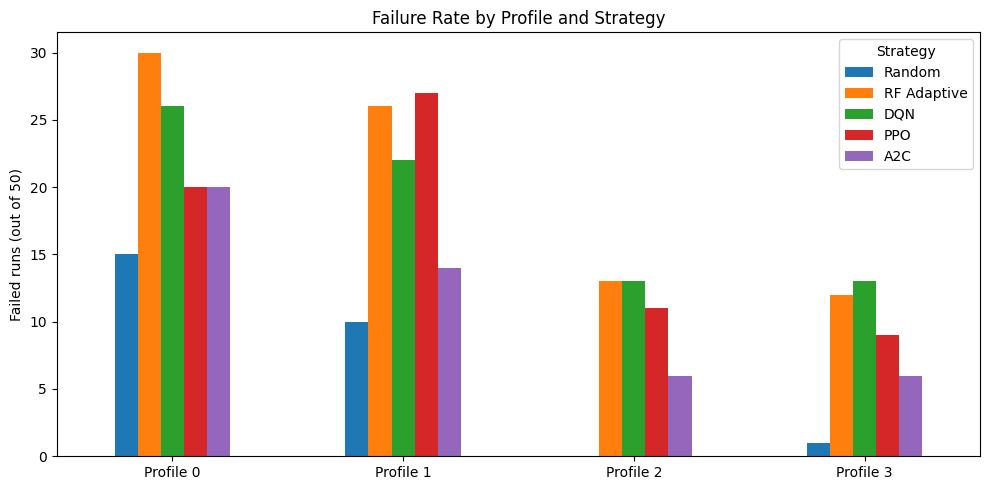

In [25]:
failure_data = {
    'Profile 0': [p0_f_rand, p0_f_rf, p0_f_dqn, p0_f_ppo, p0_f_a2c],
    'Profile 1': [p1_f_rand, p1_f_rf, p1_f_dqn, p1_f_ppo, p1_f_a2c],
    'Profile 2': [p2_f_rand, p2_f_rf, p2_f_dqn, p2_f_ppo, p2_f_a2c],
    'Profile 3': [p3_f_rand, p3_f_rf, p3_f_dqn, p3_f_ppo, p3_f_a2c],
}

failure_df = pd.DataFrame(failure_data, index=strategy_names).T
print("Failure counts (runs with no activity performed):")
print(failure_df)

fig, ax = plt.subplots(figsize=(10, 5))
failure_df.plot(kind='bar', ax=ax)
ax.set_ylabel('Failed runs (out of {})'.format(runs))
ax.set_title('Failure Rate by Profile and Strategy')
ax.legend(title='Strategy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()